         Borough  Number of Schools
0          Bronx                153
1       Brooklyn                167
2      Manhattan                153
3         Queens                103
4  Staten Island                 17


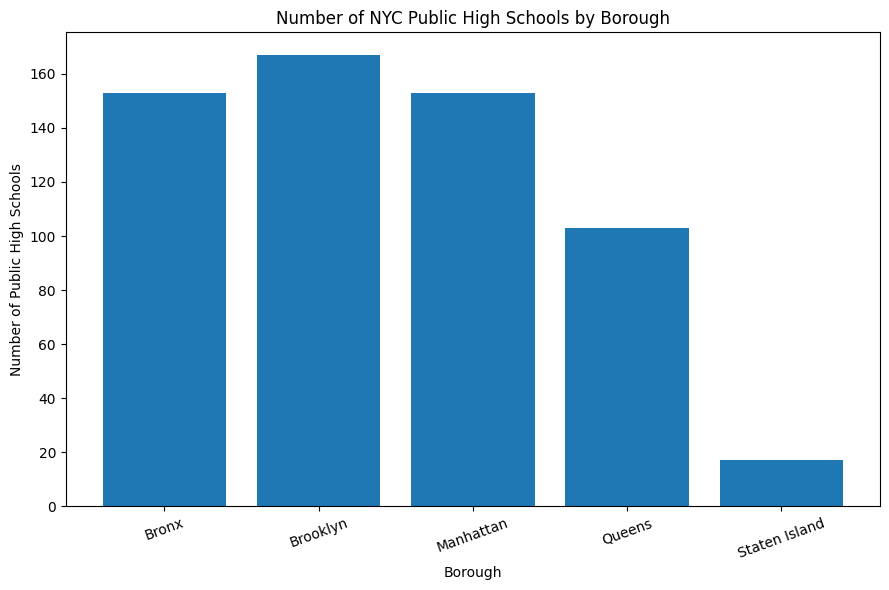

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load file
dem = pd.read_excel('Economic_poverty_index.xlsx', sheet_name='School')

# Filter to high schools only
dem_hs = dem[
    (dem['Year'] == '2021-22') &
    (dem['Grade 9'] > 0)
].copy()

# Get borough from DBN
def get_borough(dbn):
    code = str(dbn)[2].upper()
    return {
        'X': 'Bronx',
        'K': 'Brooklyn',
        'M': 'Manhattan',
        'Q': 'Queens',
        'R': 'Staten Island'
    }.get(code, 'Other')

dem_hs['Borough'] = dem_hs['DBN'].apply(get_borough)

# Count number of high schools by borough
school_counts = dem_hs.groupby('Borough')['DBN'].nunique().reset_index()
school_counts.columns = ['Borough', 'Number of Schools']

print(school_counts)

# Plot
plt.figure(figsize=(9,6))
plt.bar(school_counts['Borough'], school_counts['Number of Schools'])

plt.xlabel('Borough')
plt.ylabel('Number of Public High Schools')
plt.title('Number of NYC Public High Schools by Borough')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

         Borough  Number_of_Schools  Avg_Graduation
0          Bronx                116       83.100455
1       Brooklyn                125       82.895927
2      Manhattan                114       86.254822
3         Queens                 85       86.234112
4  Staten Island                 12       84.752114


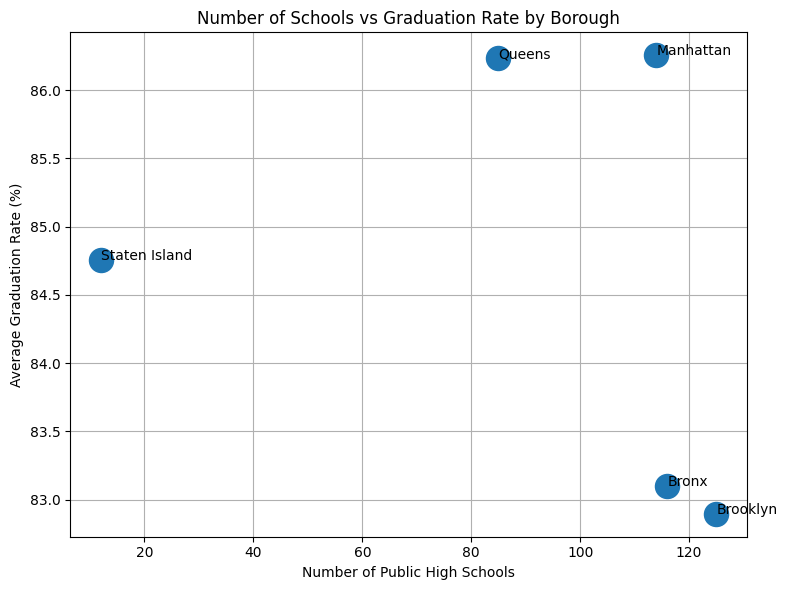

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
dem = pd.read_excel('Economic_poverty_index.xlsx', sheet_name='School')
grad = pd.read_excel('2025-graduation-rates-public-school.xlsx', sheet_name='All')

# ----------------------------
# FILTER HIGH SCHOOLS
# ----------------------------
dem_hs = dem[
    (dem['Year']=='2021-22') &
    (dem['Grade 9'] > 0)
].copy()

grad_hs = grad[
    (grad['Category']=='All Students') &
    (grad['Cohort']=='4 year August') &
    (grad['Cohort Year']==2021)
].copy()

# ----------------------------
# MERGE
# ----------------------------
df = dem_hs[['DBN']].merge(
    grad_hs[['DBN','% Grads']],
    on='DBN'
).dropna()

df['% Grads'] = pd.to_numeric(df['% Grads'], errors='coerce')
df = df.dropna()

# ----------------------------
# ADD BOROUGH
# ----------------------------
def get_borough(dbn):
    code = str(dbn)[2].upper()
    return {
        'X':'Bronx',
        'K':'Brooklyn',
        'M':'Manhattan',
        'Q':'Queens',
        'R':'Staten Island'
    }.get(code,'Other')

df['Borough'] = df['DBN'].apply(get_borough)

# ----------------------------
# AGGREGATE
# ----------------------------
agg = df.groupby('Borough').agg(
    Number_of_Schools=('DBN','count'),
    Avg_Graduation=('% Grads','mean')
).reset_index()

print(agg)

# ----------------------------
# SCATTER PLOT
# ----------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    agg['Number_of_Schools'],
    agg['Avg_Graduation'],
    s=300
)

# Add borough labels
for i,row in agg.iterrows():
    plt.annotate(
        row['Borough'],
        (row['Number_of_Schools'], row['Avg_Graduation'])
    )

plt.xlabel('Number of Public High Schools')
plt.ylabel('Average Graduation Rate (%)')
plt.title('Number of Schools vs Graduation Rate by Borough')

plt.grid(True)
plt.tight_layout()
plt.show()

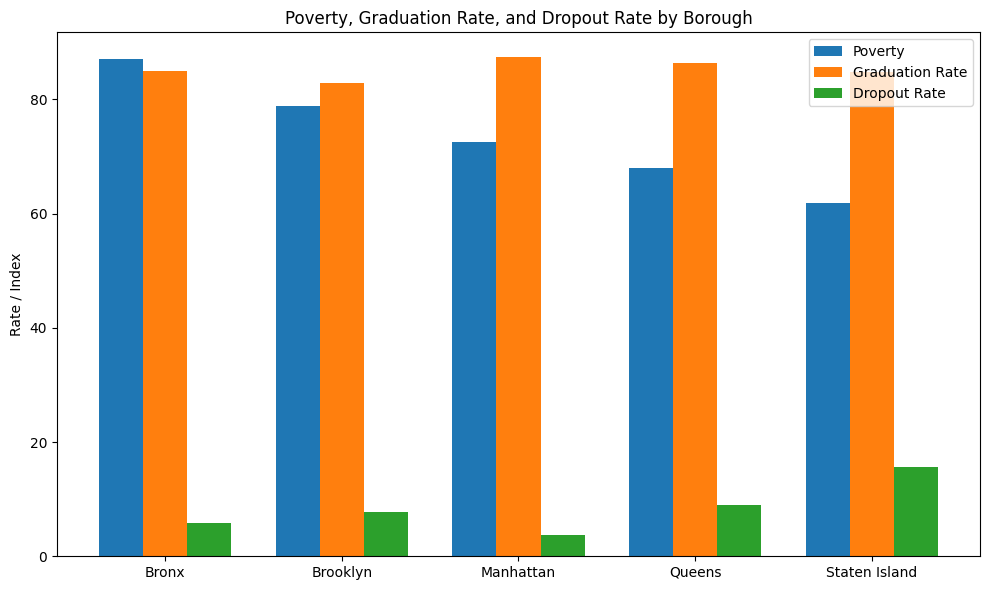

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
dem = pd.read_excel('Economic_poverty_index.xlsx', sheet_name='School')
grad = pd.read_excel('2025-graduation-rates-public-school.xlsx', sheet_name='All')

# Filter
dem_hs = dem[(dem['Year']=='2021-22') & (dem['Grade 9']>0)].copy()

grad_hs = grad[
    (grad['Category']=='All Students') &
    (grad['Cohort']=='4 year August') &
    (grad['Cohort Year']==2021)
].copy()

# Auto-find dropout column
dropout_candidates = [c for c in grad_hs.columns if 'drop' in c.lower()]
dropout_col = dropout_candidates[0]

# Merge
df = dem_hs[['DBN','Economic Need Index']].merge(
    grad_hs[['DBN','% Grads',dropout_col]],
    on='DBN'
).dropna()

# Numeric
for c in ['Economic Need Index','% Grads',dropout_col]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna()

# Borough
def get_borough(dbn):
    return {
        'X':'Bronx',
        'K':'Brooklyn',
        'M':'Manhattan',
        'Q':'Queens',
        'R':'Staten Island'
    }.get(str(dbn)[2].upper(),'Other')

df['Borough'] = df['DBN'].apply(get_borough)

# Aggregate
agg = df.groupby('Borough').agg(
    Poverty=('Economic Need Index','mean'),
    Graduation=('% Grads','mean'),
    Dropout=(dropout_col,'mean')
).reset_index()

# Scale poverty to 0-100
agg['Poverty'] = agg['Poverty']*100

# Plot
x = np.arange(len(agg))
w = 0.25

plt.figure(figsize=(10,6))

plt.bar(x-w, agg['Poverty'], width=w, label='Poverty')
plt.bar(x, agg['Graduation'], width=w, label='Graduation Rate')
plt.bar(x+w, agg['Dropout'], width=w, label='Dropout Rate')

plt.xticks(x, agg['Borough'])
plt.ylabel('Rate / Index')
plt.title('Poverty, Graduation Rate, and Dropout Rate by Borough')

plt.legend()
plt.tight_layout()
plt.show()

  District  Priority Index
5       12       45.716046
0       07       44.500706
1       08       43.832519
2       09       40.907431
4       11       39.245197
3       10       38.322586


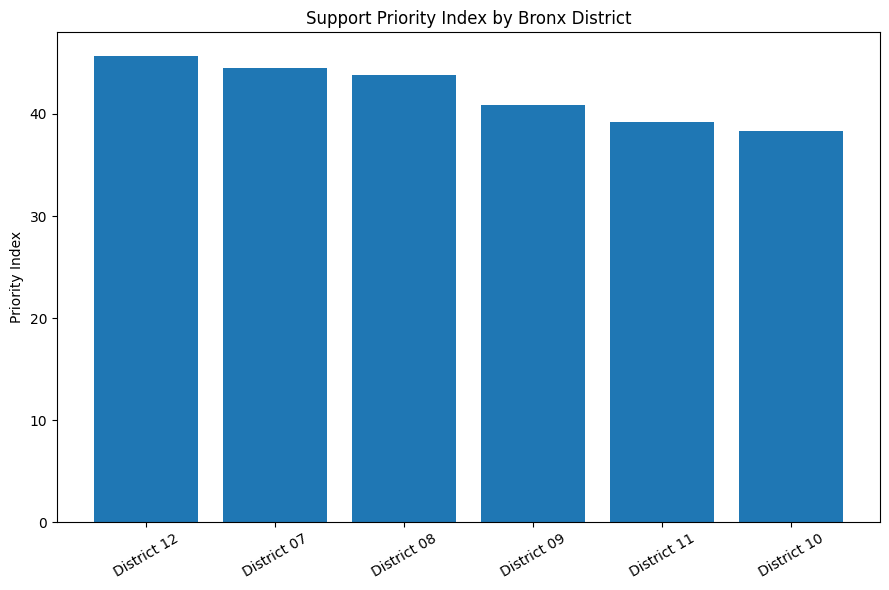

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

dem = pd.read_excel('Economic_poverty_index.xlsx', sheet_name='School')
grad = pd.read_excel('2025-graduation-rates-public-school.xlsx', sheet_name='All')

dem_hs = dem[(dem['Year']=='2021-22')&(dem['Grade 9']>0)].copy()

grad_hs = grad[
 (grad['Category']=='All Students') &
 (grad['Cohort']=='4 year August') &
 (grad['Cohort Year']==2021)
].copy()

# find dropout column
dropout_col = [c for c in grad_hs.columns if 'drop' in c.lower()][0]

df = dem_hs[['DBN','Economic Need Index']].merge(
    grad_hs[['DBN','% Grads',dropout_col]],
    on='DBN'
).dropna()

for c in ['Economic Need Index','% Grads',dropout_col]:
    df[c]=pd.to_numeric(df[c],errors='coerce')

df=df.dropna()

# Bronx only
df = df[df['DBN'].astype(str).str[2].str.upper()=='X'].copy()

# District
df['District']=df['DBN'].astype(str).str[:2]

# Convert to risks
df['Need Risk']=df['Economic Need Index']*100
df['Graduation Risk']=100-df['% Grads']
df['Dropout Risk']=df[dropout_col]

# Priority Index
df['Priority Index'] = (
    0.4*df['Need Risk'] +
    0.35*df['Graduation Risk'] +
    0.25*df['Dropout Risk']
)

# Average by district
district_scores = df.groupby('District')['Priority Index'].mean().reset_index()

# Rank
district_scores = district_scores.sort_values(
    by='Priority Index',
    ascending=False
)

print(district_scores)

# Graph
plt.figure(figsize=(9,6))
plt.bar(
    'District ' + district_scores['District'],
    district_scores['Priority Index']
)

plt.title('Support Priority Index by Bronx District')
plt.ylabel('Priority Index')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

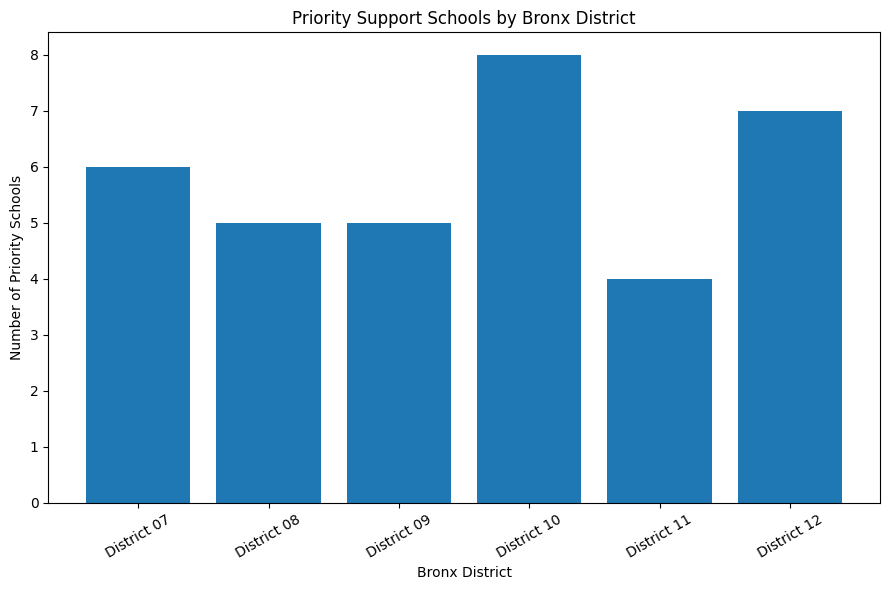

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
dem = pd.read_excel('Economic_poverty_index.xlsx', sheet_name='School')
grad = pd.read_excel('2025-graduation-rates-public-school.xlsx', sheet_name='All')

# Filter high schools
dem_hs = dem[(dem['Year']=='2021-22') & (dem['Grade 9']>0)].copy()

grad_hs = grad[
    (grad['Category']=='All Students') &
    (grad['Cohort']=='4 year August') &
    (grad['Cohort Year']==2021)
].copy()

# Find dropout column
dropout_col = [c for c in grad_hs.columns if 'drop' in c.lower()][0]

# Merge
df = dem_hs[['DBN','School Name','Economic Need Index']].merge(
    grad_hs[['DBN','% Grads',dropout_col]],
    on='DBN'
).dropna()

# Numeric conversion
for c in ['Economic Need Index','% Grads',dropout_col]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna()

# Bronx only
df['Borough Code'] = df['DBN'].astype(str).str[2].str.upper()
df['District'] = df['DBN'].astype(str).str[:2]

bronx = df[df['Borough Code']=='X'].copy()

# Define priority school (2 of 3 signals)
high_need_cutoff = df['Economic Need Index'].quantile(0.75)
low_grad_cutoff = df['% Grads'].quantile(0.25)
high_dropout_cutoff = df[dropout_col].quantile(0.75)

bronx['High Need'] = bronx['Economic Need Index'] >= high_need_cutoff
bronx['Low Graduation'] = bronx['% Grads'] <= low_grad_cutoff
bronx['High Dropout'] = bronx[dropout_col] >= high_dropout_cutoff

bronx['Risk Count'] = (
    bronx['High Need'].astype(int) +
    bronx['Low Graduation'].astype(int) +
    bronx['High Dropout'].astype(int)
)

bronx['Priority School'] = bronx['Risk Count'] >= 2

# Count by district
district_counts = bronx.groupby('District')['Priority School'].sum().reset_index()
district_counts.columns = ['District','Priority Schools']

# Graph only
plt.figure(figsize=(9,6))

plt.bar(
    'District ' + district_counts['District'],
    district_counts['Priority Schools']
)

plt.title('Priority Support Schools by Bronx District')
plt.xlabel('Bronx District')
plt.ylabel('Number of Priority Schools')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()